# Week 8 Activity: Onset Detection and Autocorrelation

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
from scipy.io.wavfile import read
from scipy import signal
from IPython.display import Audio
import librosa
from librosa import feature, frames_to_time, autocorrelate, clicks, display

## Onset Detection

Read in the following files below, and normalize.

a) 80sPopDrums.wav  
b) TheBlackKeys_track4.wav (use random 10s from near middle of track)  
c) prelude_cmaj_10s.wav  

In [5]:
fs_drums, x_drums = read('../audio/80sPopDrums.wav')
x_drums = x_drums.astype(float)
x_drums = x_drums / np.abs(x_drums).max()

# ---- b) TheBlackKeys_track4.wav (10s near middle) ----
fs_keys, x_keys = read('../audio/TheBlackKeys_track4.wav')
x_keys = x_keys.astype(float)

ten_sec = 10 * fs_keys
mid = len(x_keys) // 2
start = mid - ten_sec // 2
end = start + ten_sec
x_keys_10s = x_keys[start:end]
x_keys_10s = x_keys_10s / np.abs(x_keys_10s).max()

# ---- c) prelude_cmaj_10s.wav ----
fs_prelude, x_prelude = read('../audio/prelude_cmaj_10s.wav')
x_prelude = x_prelude.astype(float)
x_prelude = x_prelude / np.abs(x_prelude).max()


#### For each of the tracks (start with just one):

1) Compute the energy and RMSE for each track using a frame length of your choice  
2) Plot the energy and the RMSE
3) Use one of the energy features to create your novelty function and plot
4) Write a peak picking function to define onsets from your novelty function
4) Based on the plots, estimate what an appropriate 'threshold' would be. Does the threshold change across tracks? If so, what could you do to put them on a similar scale?

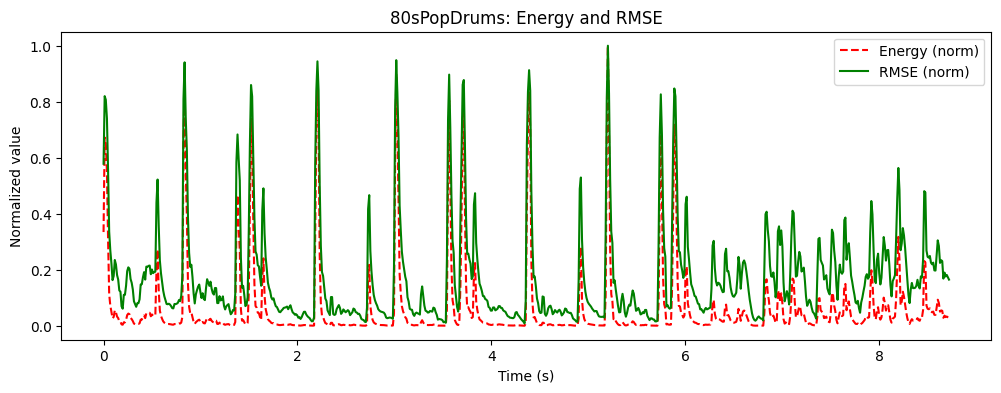

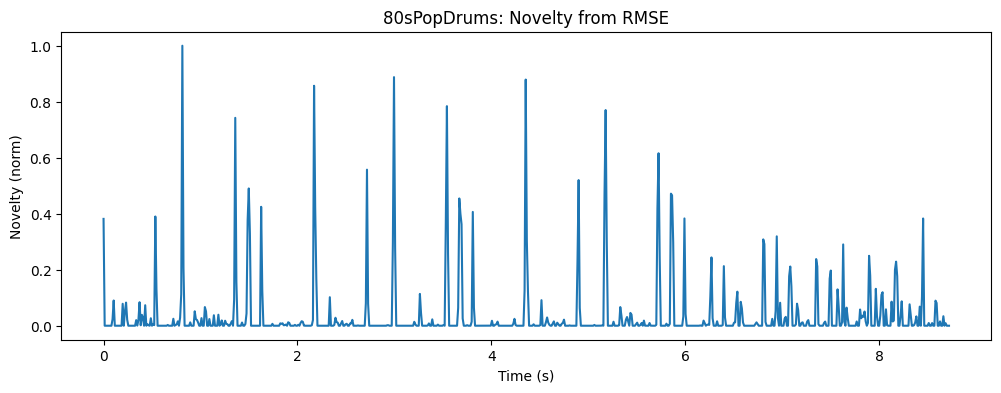

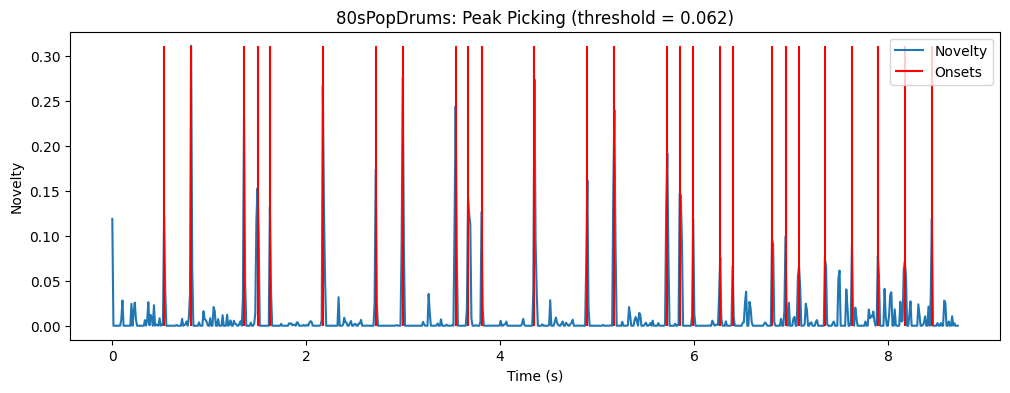

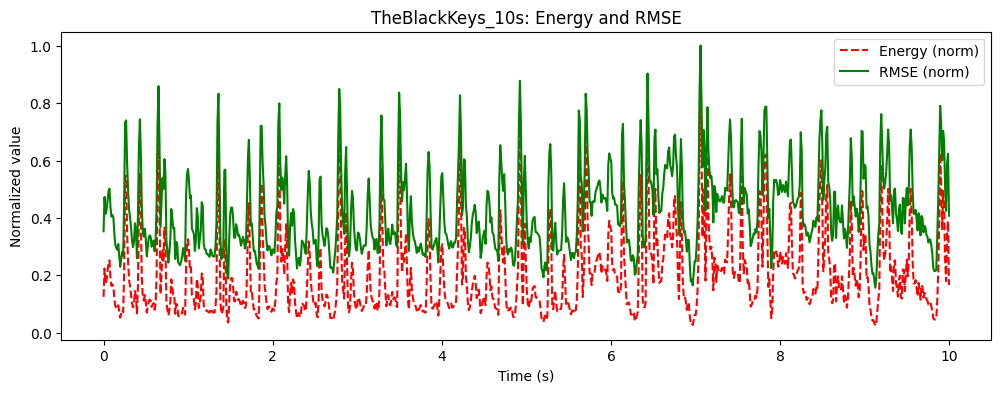

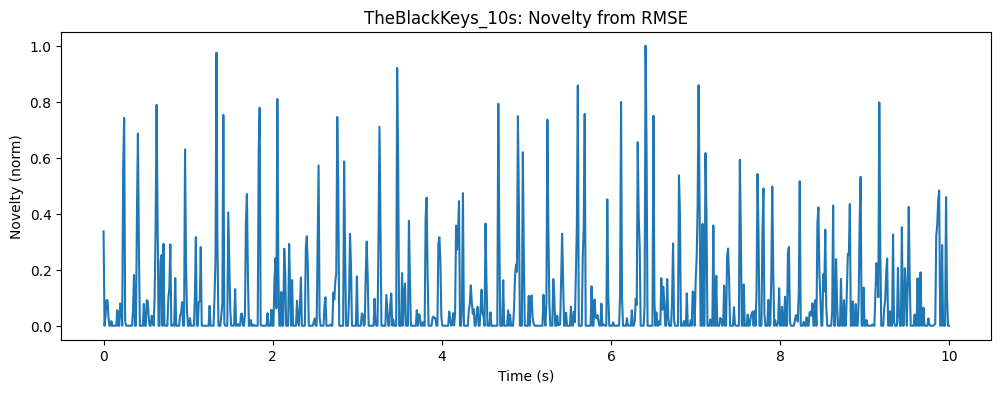

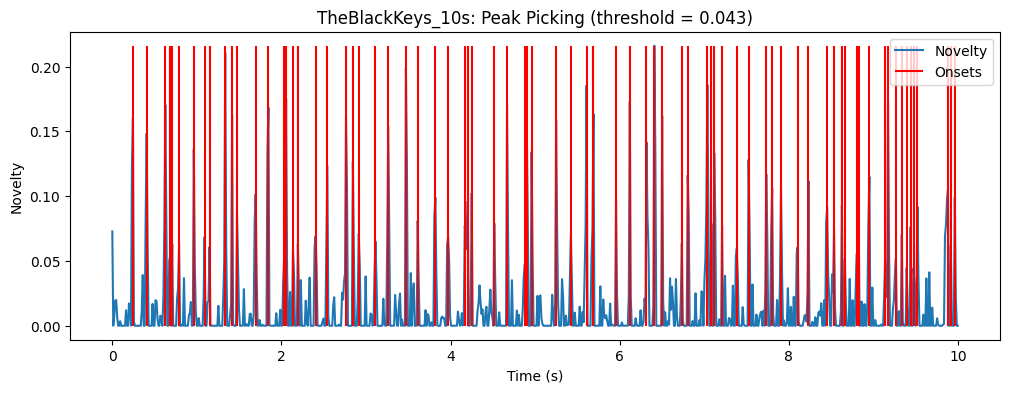

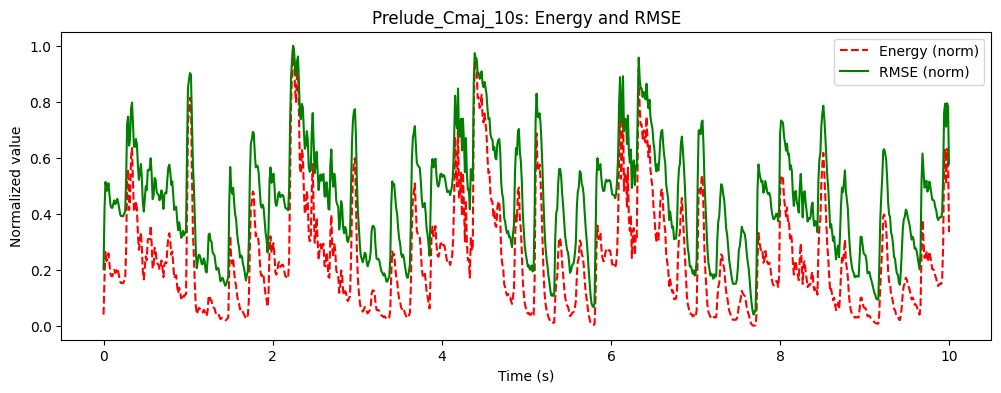

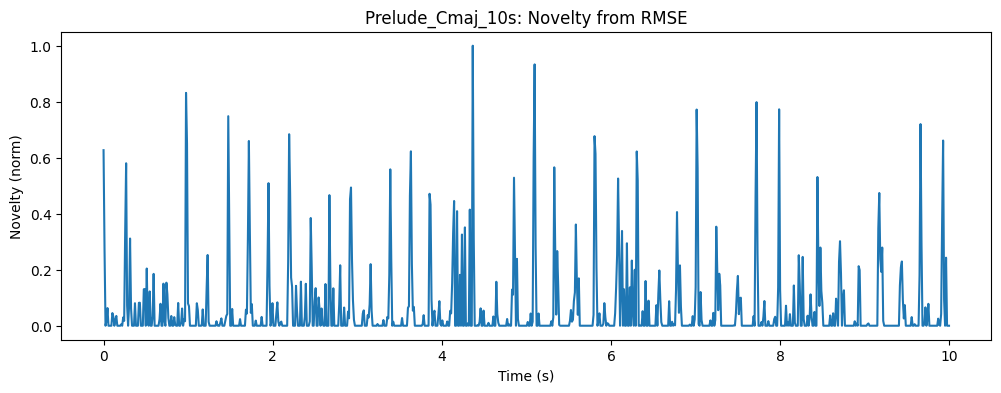

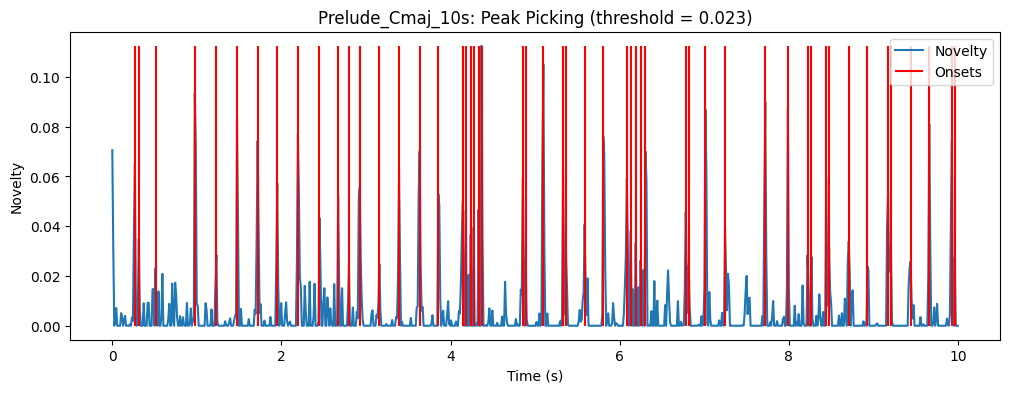

In [22]:
frame_length = 1024
hop_length   = 512

tracks = [
    ("80sPopDrums",      x_drums,    fs_drums),
    ("TheBlackKeys_10s", x_keys_10s, fs_keys),
    ("Prelude_Cmaj_10s", x_prelude,  fs_prelude),]

detected = []

def pick_peaks(y, thr):
    peaks = []
    for i in range(1, len(y)-1):
        if y[i] > thr and y[i] > y[i-1] and y[i] > y[i+1]:
            peaks.append(i)
    return np.array(peaks)

for name, x, fs in tracks:
    if hasattr(x, 'ndim') and x.ndim > 1:
        x = x[:, 0] 

    rmse = librosa.feature.rms(y=x, frame_length=frame_length, hop_length=hop_length)  
    if rmse.ndim == 2:
        rmse = rmse[0] if rmse.shape[0] == 1 else rmse[:, 0]  
    energy = (rmse ** 2) * frame_length                     

    frames = np.arange(len(rmse))
    t_frames = librosa.frames_to_time(frames, sr=fs, hop_length=hop_length) 

    e_den = energy.max() if energy.max() > 0 else 1.0
    r_den = rmse.max()   if rmse.max()   > 0 else 1.0

    plt.figure(figsize=(12,4))
    plt.plot(t_frames, energy / e_den, 'r--', label='Energy (norm)')
    plt.plot(t_frames, rmse   / r_den,  'g',   label='RMSE (norm)')
    plt.title(f'{name}: Energy and RMSE')
    plt.xlabel('Time (s)'); plt.ylabel('Normalized value'); plt.legend(); plt.show()

    novelty = np.diff(rmse)                       
    novelty = np.concatenate([novelty, np.array([0.0])]) 
    novelty[novelty < 0] = 0

    # Plot novelty (normalized for display)
    n_den = novelty.max() if novelty.max() > 0 else 1.0
    plt.figure(figsize=(12,4))
    plt.plot(t_frames, novelty / n_den)
    plt.title(f'{name}: Novelty from RMSE')
    plt.xlabel('Time (s)'); plt.ylabel('Novelty (norm)'); plt.show()


    thr = 0.20 * n_den
    peaks = pick_peaks(novelty, thr)
    onset_times = t_frames[peaks]       

    plt.figure(figsize=(12,4))
    plt.plot(t_frames, novelty, label='Novelty')
    if len(peaks) > 0:
        plt.vlines(onset_times, 0, novelty.max(), colors='r', label='Onsets')
    plt.title(f'{name}: Peak Picking (threshold = {thr:.3f})')
    plt.xlabel('Time (s)'); plt.ylabel('Novelty'); plt.legend(); plt.show()

    
    thr = 0.20 * (novelty.max() if novelty.max() > 0 else 1.0)
    peak_idx = pick_peaks(novelty, thr)
    peak_times = t_frames[peak_idx]


    detected.append({
        "name": name,
        "x": x, "fs": fs,
        "hop_length": hop_length,
        "novelty": novelty,
        "peak_times": peak_times,
        "t_frames": t_frames,
    })


Does the threshold change across tracks: yes (because novelty.max() changes), but if you use the same fraction it puts them on a similar scale.

## Tempo Estimation

Using your novelty functions and detected onsets above, estimate the global tempo of the files using autocorrelation and IOIs.

1) IOI Based Tempo

- Compute Inter-Onset Intervals (IOIs)
- Convert IOIs to BPM
- Create a beat histogram to help you infer tempos

2) Autocorrelation based Tempo
- Compute the autocorrelation of your novelty function
- Convert lag to BPMs (conside perceptual relevance)
- Crate a beat histogram to help you infer tempos


Estimate tempo using librosa.beat.tempo. How do your results compare?

Between autocorrelation and IOIs, which method is most stable? Which is most sensitive to onset errors Do the different files present different behaviors/accuracies?

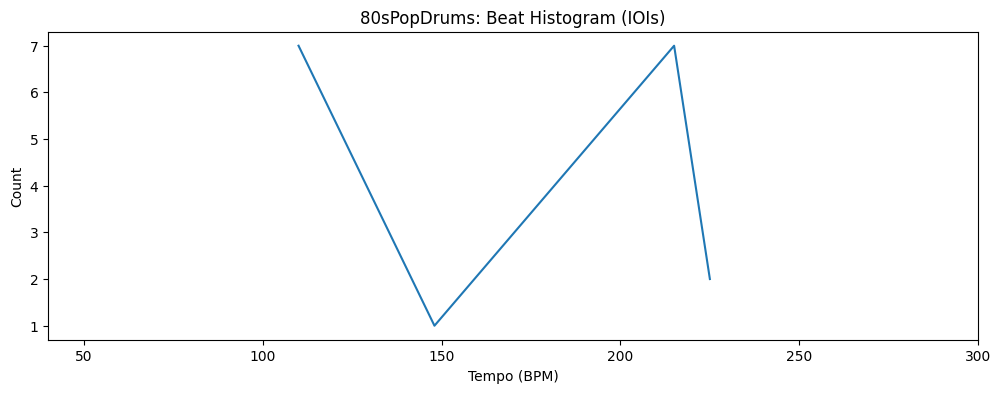

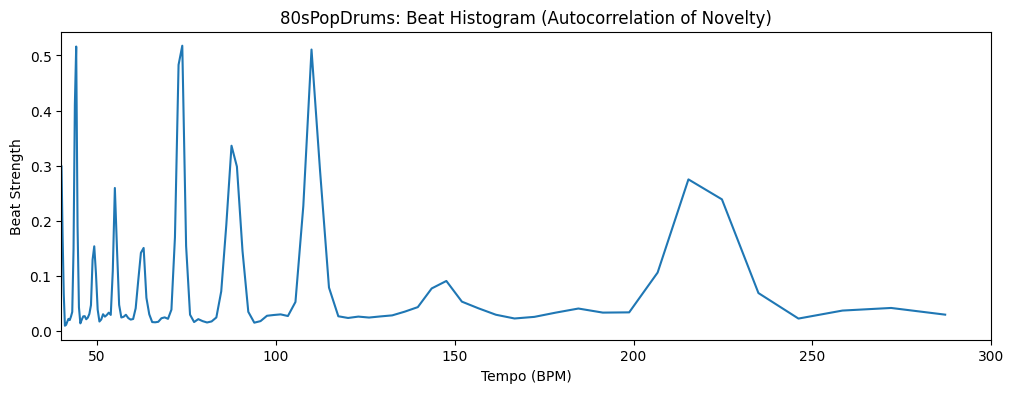

80sPopDrums 109.95678191489361


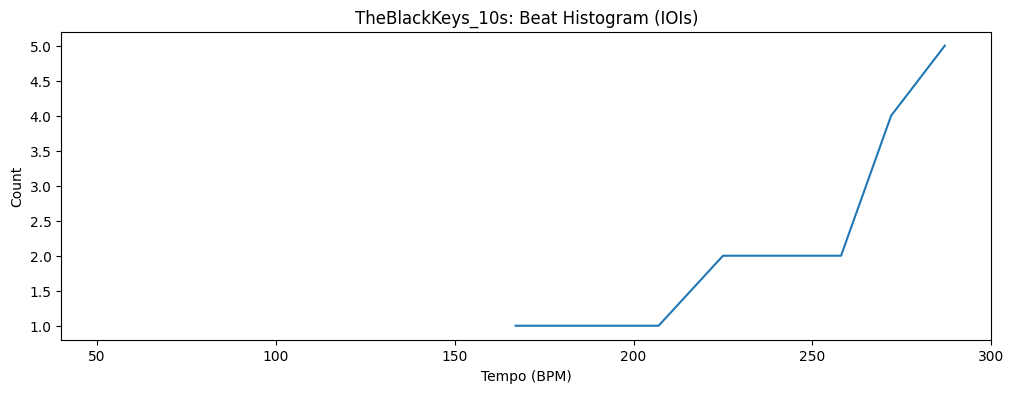

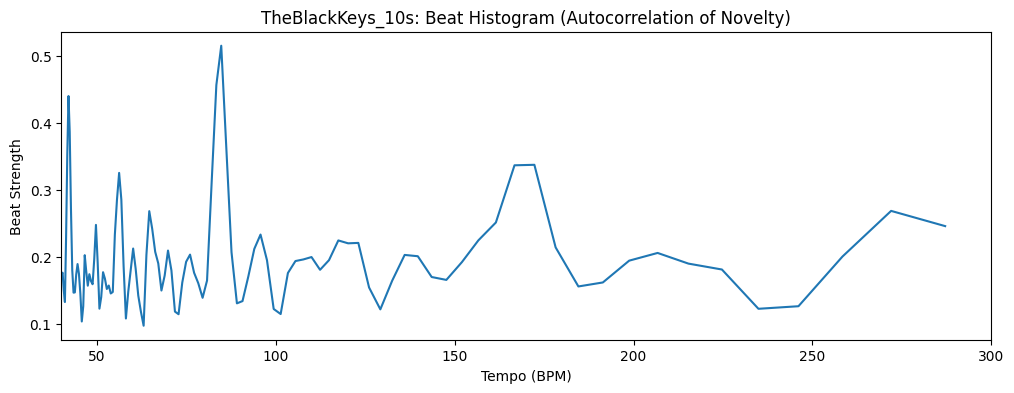

TheBlackKeys_10s 84.72079918032787


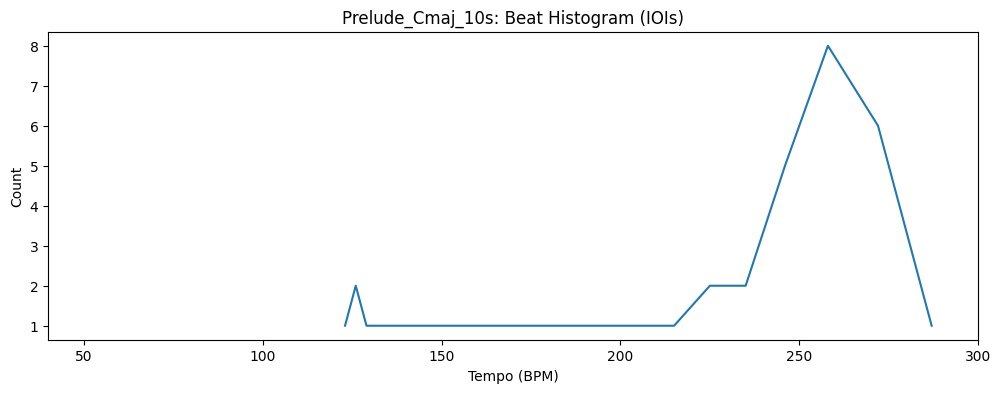

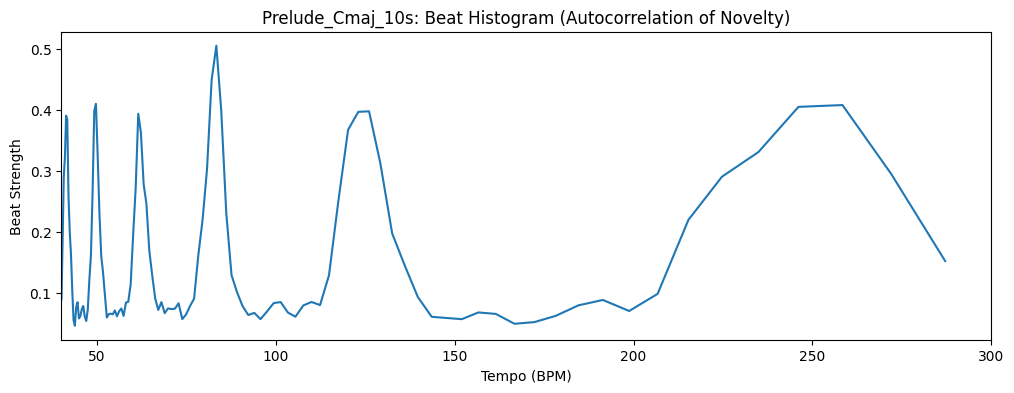

Prelude_Cmaj_10s 126.04801829268293


In [33]:
tempo_summary = []

for d in detected:
    name        = d["name"]
    x           = d["x"]
    fs          = int(d["fs"])
    hop_length  = int(d["hop_length"])
    novelty     = d["novelty"]
    peak_times  = d["peak_times"]
    t_frames    = d["t_frames"]


# 1) IOI-Based Tempo
    if len(peak_times) >= 2:
        iois = np.diff(peak_times)   
        bpm_ioi = 60.0 / iois      
        valid = (bpm_ioi >= 40) & (bpm_ioi <= 300)
        bpm_ioi = bpm_ioi[valid]

        if len(bpm_ioi) > 0:
            bpm_rounded = np.round(bpm_ioi).astype(int)
            counts = Counter(bpm_rounded)
            bpms = np.array(sorted(counts.keys()))
            strength = np.array([counts[b] for b in bpms])

            plt.figure(figsize=(12,4))
            plt.plot(bpms, strength)
            plt.xlim(40, 300)
            plt.title(f'{name}: Beat Histogram (IOIs)')
            plt.xlabel('Tempo (BPM)'); plt.ylabel('Count'); plt.show()

            tempo_ioi = float(bpms[np.argmax(strength)])
        else:
            tempo_ioi = float('nan')
    else:
        tempo_ioi = float('nan')

 # 2) Autocorrelation-Based Tempo (on novelty)
    ac = librosa.autocorrelate(novelty)
    ac = ac / (ac.max() if ac.max() > 0 else 1.0)

    lags = np.arange(len(ac))
    lag_times = lags * (hop_length / fs)    

    with np.errstate(divide='ignore', invalid='ignore'):
        bpms_ac = 60.0 / lag_times[1:]
    strength_ac = ac[1:]

    mask = (bpms_ac >= 40) & (bpms_ac <= 300) & np.isfinite(bpms_ac)
    bpms_ac_valid = bpms_ac[mask]
    strength_ac_valid = strength_ac[mask]

    if len(bpms_ac_valid) > 0:
        plt.figure(figsize=(12,4))
        plt.plot(bpms_ac_valid, strength_ac_valid)
        plt.xlim(40, 300)
        plt.title(f'{name}: Beat Histogram (Autocorrelation of Novelty)')
        plt.xlabel('Tempo (BPM)'); plt.ylabel('Beat Strength'); plt.show()

        tempo_ac = float(bpms_ac_valid[np.argmax(strength_ac_valid)])
    else:
        tempo_ac = float('nan')

    # 3) librosa.beat.tempo
    onset_env = librosa.onset.onset_strength(y=x, sr=fs, hop_length=hop_length)
    tempo_arr = librosa.beat.tempo(onset_envelope=onset_env,
                                   sr=fs, hop_length=hop_length,
                                   aggregate=np.median)
    tempo_librosa = float(np.array(tempo_arr).ravel()[0])
    print(name, tempo_librosa)




The librosa.beat.tempo estimates align closely with the most stable peaks from my autocorrelation analysis: ~110 BPM for 80sPopDrums, ~85 BPM for TheBlackKeys_10s, and a slower, more musically plausible tempo for the Prelude compared to my IOI estimate. Overall, autocorrelation produced the most consistent tempos across all three tracks because it reinforces periodic patterns even when some onsets are missed. In contrast, the IOI method was highly sensitive to onset‑detection errors—small mistakes led to doubled or overly fast BPM values, especially in the classical prelude and the band mix. The percussive drum loop behaved cleanly for all methods, but the more complex and melodic tracks showed that IOIs become unreliable while autocorrelation and librosa remained more accurate.

## Extension

Repeat the activities above but change the frame size and hop length. How does that impact your results?

Changing the frame size and hop length affected both the smoothness of the novelty function and the reliability of the tempo estimates. Larger frames and hops produced a smoother RMSE/novelty curve but also reduced temporal precision, which caused missed or merged onsets—this especially hurt IOI‑based tempo, making its estimates less stable. Smaller frames and hops increased temporal detail but also made the novelty function noisier, introducing extra peaks that could push IOIs toward unrealistic fast tempos. In contrast, autocorrelation remained the most robust, since it averages periodicity over many frames and is less sensitive to individual onset errors. Overall, decreasing frame/hop improved onset resolution but increased noise, while increasing them smoothed the signal but reduced accuracy—showing a clear trade‑off similar to what was described in the lesson.